# Project 1 - Divar Real Estate Analysis

This notebook merges two teammates' work into one pipeline: `Erfan_Project1.ipynb` (Descriptive Q4, Q5, and Hypothesis Test 3) and `Mesbah_Project1.ipynb` (Descriptive Q8, Q9, and Hypothesis Tests 1, 2). Both notebooks did their own data cleaning, so this version combines the two preprocessing pipelines into one, picks the better approach where they overlap, and keeps credit for who built what (`@author` tags on functions).

Requirements and dataset dictionary: `QBC12 _ AI _ Project 1.md`.

**Structure:**
1. Initial data look + schema check
2. Unified preprocessing pipeline
3. Descriptive stats: Q4, Q5, Q8, Q9 (in the order the assignment asks them)
4. Hypothesis tests: H1, H2, H3


In [1]:
# unified imports - combining what all notebooks used
import re
import os
import json as js
import warnings

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.path import Path
import seaborn as sns

import folium
from folium.plugins import HeatMap

from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


## 1. First look at the data

Before cleaning anything, just loading the file and checking the basics: shape, dtypes, how many nulls per column. This is mostly Erfan's original exploration style (quick describe/info checks).

In [2]:
df = pd.read_csv("Divar.csv", low_memory=False)
print("shape:", df.shape)
df.head()

shape: (1000000, 61)


,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,NaN,NaN,NaN,سه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,3,یک,NaN,NaN,NaN,True,True,True,۱۳۸۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,NaN,مقطوع,750000000.0,False,False,750000000.0,NaN,26000000.0,NaN,NaN,132.0,NaN,NaN,3,سه,NaN,NaN,NaN,True,True,True,۱۴۰۱,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,NaN,مقطوع,950000000.0,False,False,950000000.0,NaN,95000000.0,NaN,NaN,90.0,NaN,NaN,4,یک,NaN,NaN,NaN,True,False,True,۱۴۰۰,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.0,single_page,NaN,4,دو,6,NaN,true,True,True,True,۱۴۰۳,NaN,NaN,package,NaN,NaN,shoofaj,air_conditioner,squat_seat,NaN,NaN,north,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()
print()
print("null % per column (sorted):")
print(((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False).head(15))

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

**Schema check (@author: Mesbah).** Checked whether the 61 columns are actually named right, since scraped data sometimes has shifted headers. They're fine here - all columns line up. The one real naming issue: `has_restroom` is not actually True/False, it holds text like `squat_seat`/`squat`/`seat`/`unselect`, so it gets renamed to `restroom_type` to avoid confusion later.

Also checked `location_latitude`/`location_longitude` - they're clean, all inside Iran's bounding box, and get renamed to `latitude`/`longitude` for shorter code.

In [4]:
# @author: Mesbah
EXPECTED_NAMED = {
    "has_security_guard", "has_barbecue", "building_direction",
    "has_pool", "has_jacuzzi", "has_sauna", "floor_material",
}
TAIL_SCHEMA = [
    "restroom_type", "has_security_guard", "has_barbecue", "building_direction",
    "has_pool", "has_jacuzzi", "has_sauna", "floor_material",
]

def realign_schema(df):
    """Check column names are correct; only remap positionally if the header looks corrupt."""
    out = df.copy()
    if "Unnamed: 0" in out.columns:
        out = out.drop(columns=["Unnamed: 0"])

    present = EXPECTED_NAMED.intersection(out.columns)
    if len(present) == len(EXPECTED_NAMED):
        print(f"[schema] looks fine: {len(present)}/{len(EXPECTED_NAMED)} tail columns found by name.")
        if "has_restroom" in out.columns and "restroom_type" not in out.columns:
            out = out.rename(columns={"has_restroom": "restroom_type"})
            print("[schema] renamed has_restroom -> restroom_type (it's not a real boolean).")
    else:
        missing = EXPECTED_NAMED - present
        print(f"[schema] WARNING: header looks off (missing {missing}). Using positional fallback.")
        new_cols = list(out.columns)
        new_cols[-len(TAIL_SCHEMA):] = TAIL_SCHEMA
        out.columns = new_cols

    rename_geo = {}
    if "latitude" not in out.columns:
        cand = [c for c in out.columns if "lat" in c.lower()]
        if cand: rename_geo[cand[0]] = "latitude"
    if "longitude" not in out.columns:
        cand = [c for c in out.columns if "lon" in c.lower()]
        if cand: rename_geo[cand[0]] = "longitude"
    out = out.rename(columns=rename_geo)

    if {"latitude", "longitude"}.issubset(out.columns):
        lat = pd.to_numeric(out["latitude"], errors="coerce")
        lon = pd.to_numeric(out["longitude"], errors="coerce")
        valid = lat.between(24, 40) & lon.between(44, 64)   # Iran bounding box
        out["latitude"] = lat.where(valid)
        out["longitude"] = lon.where(valid)
        print(f"[geo] {100*valid.mean():.1f}% of rows have valid Iran coordinates.")

    return out

df = realign_schema(df)
print("shape after schema check:", df.shape)

[schema] looks fine: 7/7 tail columns found by name.
[schema] renamed has_restroom -> restroom_type (it's not a real boolean).
[geo] 65.6% of rows have valid Iran coordinates.
shape after schema check: (1000000, 60)


## 2. Unified preprocessing pipeline

Both notebooks did their own cleaning. Instead of picking one or the other, this section merges them: each step is its own function (so later, for the ML part, we can call or skip a step without touching the whole dataframe), and where both authors solved the same problem, we kept whichever version gave cleaner results.

Rule we followed: don't overwrite a raw column unless it's genuinely broken in its original form (like Persian digits, or `rooms_count` text). Everything else goes into a new column so the original is still there if we need it.

### 2.1 Drop columns we don't need

In [5]:
# @author: Erfan
def drop_high_null_columns(df, threshold=97.1943):
    """Drop columns where almost everything is missing. Threshold picked by
    looking at the null% list above - there's a natural gap right around here
    (property_type at 97.29% vs has_sauna at 97.15%), so this cuts the
    daily-rent-only fields (capacity, special-day rent prices, etc.) without
    touching anything both of us actually use."""
    df = df.copy()
    null_pct = df.isnull().mean() * 100
    to_drop = null_pct[null_pct > threshold].index.tolist()
    print(f"dropping {len(to_drop)} high-null columns: {to_drop}")
    return df.drop(columns=to_drop)

def drop_unnecessary_columns(df):
    """A few columns neither of us ended up using anywhere."""
    df = df.copy()
    to_drop = [c for c in ["rent_mode", "credit_mode", "floor_material"] if c in df.columns]
    print(f"dropping {to_drop}")
    return df.drop(columns=to_drop)

df = drop_high_null_columns(df)
df = drop_unnecessary_columns(df)
print("shape now:", df.shape)

dropping 7 high-null columns: ['rent_to_single', 'property_type', 'extra_person_capacity', 'cost_per_extra_person', 'rent_price_on_regular_days', 'rent_price_on_special_days', 'rent_price_at_weekends']
dropping ['rent_mode', 'credit_mode', 'floor_material']
shape now: (1000000, 50)


### 2.2 Fixing Persian digits, rooms_count, and construction_year

These three columns are genuinely broken in their raw form (Persian numerals, Persian words for room counts), so per our own rule these get overwritten in place instead of getting a new column - there's nothing useful left in the raw version to preserve.

In [6]:
# @author: Mesbah
_PERSIAN_DIGITS = "۰۱۲۳۴۵۶۷۸۹"
_ARABIC_DIGITS = "٠١٢٣٤٥٦٧٨٩"
_DIGIT_MAP = {ord(p): str(i) for i, p in enumerate(_PERSIAN_DIGITS)}
_DIGIT_MAP.update({ord(a): str(i) for i, a in enumerate(_ARABIC_DIGITS)})

def fa_to_en_digits(value):
    """Turn Persian/Arabic digits into normal ASCII digits."""
    if pd.isna(value):
        return value
    return str(value).translate(_DIGIT_MAP)


# @author: Erfan & Mesbah
ROOMS_MAP = {"بدون اتاق": 0, "یک": 1, "دو": 2, "سه": 3, "چهار": 4, "پنج یا بیشتر": 5}

def map_rooms_count(df, col="rooms_count"):
    out = df.copy()
    out["rooms_count"] = out[col].astype("string").str.strip().map(ROOMS_MAP).astype("Int64")
    return out

df = map_rooms_count(df)
print(df["rooms_count"].value_counts(dropna=False).sort_index())

rooms_count
0        75898
1       192083
2       404050
3       138633
4        21371
5        13864
<NA>    154101
Name: count, dtype: Int64


In [7]:
# @author: Erfan & Mesbah
# Mesbah's version keeps a flag for "before year X" instead of silently
# clamping it, and Erfan's version has an extra step that tries to guess the
# year from the listing description when the structured field is empty
# (using words like "newly built" or an explicit year mention). Merged both.

def _extract_year_from_description(text):
    """Erfan's idea: try to find a construction year mentioned in the free text."""
    if pd.isna(text):
        return np.nan
    text = fa_to_en_digits(str(text))
    if any(kw in text for kw in ["نوساز", "کلید نخورده", "کلیدنخورده", "صفر"]):
        return 1403.0  # these phrases basically mean "brand new"
    m = re.search(r"ساخت\s*(1[34]\d{2})", text) or re.search(r"(1[34]\d{2})\s*ساخت", text)
    if m:
        return float(m.group(1))
    return np.nan

def clean_construction_year(df, col="construction_year"):
    out = df.copy()
    raw = out[col].astype("string").map(fa_to_en_digits)

    is_pre = raw.str.contains("قبل", na=False)   # e.g. "قبل از 1370" (before 1370)
    out["is_pre_threshold_year"] = is_pre.fillna(False)

    year = raw.str.extract(r"(\d{4})", expand=False)
    out["construction_year"] = pd.to_numeric(year, errors="coerce")

    # try to backfill still-missing years from the description text
    missing = out["construction_year"].isna()
    if missing.any() and "description" in out.columns:
        extracted = out.loc[missing, "description"].map(_extract_year_from_description)
        out.loc[missing, "construction_year"] = extracted

    # clip anything outside a sane range (catches garbage 4-digit extractions)
    out["construction_year"] = out["construction_year"].clip(lower=1364.0, upper=1403.0)
    return out

df = clean_construction_year(df)
print(df["construction_year"].describe())
print("rows flagged 'before threshold':", int(df["is_pre_threshold_year"].sum()))

count    821714.000000
mean       1393.867392
std           8.282793
min        1364.000000
25%        1390.000000
50%        1395.000000
75%        1401.000000
max        1403.000000
Name: construction_year, dtype: float64
rows flagged 'before threshold': 20637


### 2.3 Amenities (has_pool, has_elevator, etc.)

Mesbah's version is more careful about telling apart True/False/"unselect"/missing before touching a column. Erfan's version covers more amenity columns (gas, water, electricity, parking, warehouse, is_rebuilt) and has good keyword lists from actually reading listing text. So the merged version uses Mesbah's careful True/False handling, but with Erfan's wider column list and combined keyword lists (more keywords per amenity = catches more real mentions in the text).

In [8]:
# @author: Erfan & Mesbah
AMENITY_REGEX = {
    "has_pool":           r"استخر|مجموعه آبی|استخردار",
    "has_sauna":          r"سونا",
    "has_jacuzzi":        r"جکوزی",
    "has_security_guard": r"نگهبان|حراست|سرایدار|لابی‌?من|دوربین مداربسته",
    "has_barbecue":       r"باربیکیو|کباب.?پز|آتشکده",
    "has_elevator":       r"آسانسور|اسانسور|لاین آسانسور",
    "has_balcony":        r"بالکن|تراس|ایوان|روف گاردن|بهار.?خواب",
    "has_gas":            r"گاز|فول امکانات|انشعابات کامل|انشعاب گاز",
    "has_water":          r"انشعاب آب|انشعابات کامل|فول امکانات",
    "has_electricity":    r"انشعاب برق|انشعابات کامل|فول امکانات",
    "has_parking":        r"پارکینگ",
    "has_warehouse":      r"انباری|انبار",
    "is_rebuilt":         r"بازسازی|نوسازی|صفر تا صد|کلید نخورده|شیک",
}

_TRUE_TOKENS = {"true", "1", "yes", "بله", "دارد"}
_FALSE_TOKENS = {"false", "0", "no", "خیر", "ندارد"}

def _coerce_bool_scalar(x):
    """Map one cell to True / False / missing, being explicit about weird tokens like 'unselect'."""
    if isinstance(x, bool):
        return x
    if x is None or x is pd.NA or (isinstance(x, float) and pd.isna(x)):
        return pd.NA
    t = str(x).strip().lower()
    if t in _TRUE_TOKENS:
        return True
    if t in _FALSE_TOKENS:
        return False
    return pd.NA  # unknown token (e.g. 'unselect') -> treat as missing, let text mining try

def to_nullable_bool(s):
    mapped = s.astype(object).map(_coerce_bool_scalar)
    mask = mapped.isna().to_numpy(dtype=bool)
    vals = mapped.fillna(False).astype(bool).to_numpy(dtype=bool)
    return pd.Series(pd.arrays.BooleanArray(vals, mask), index=s.index)

def impute_amenities(df, regex_map=AMENITY_REGEX, text_cols=("title", "description")):
    """Fill missing amenity booleans by scanning the listing text for keywords."""
    out = df.copy()
    blob = out[list(text_cols)].astype("string").fillna("").agg(" ".join, axis=1)
    audit = {}
    for col, pattern in regex_map.items():
        if col not in out.columns:
            continue
        s = to_nullable_bool(out[col])
        na_before = int(s.isna().sum())
        na_mask = s.isna()
        text_hit = pd.Series(False, index=out.index)
        if na_mask.any():
            text_hit.loc[na_mask] = blob.loc[na_mask].str.contains(pattern, regex=True, na=False).to_numpy(dtype=bool)
        recovered = int(text_hit.sum())
        s = s.mask(na_mask & text_hit, True)
        s = s.fillna(False).astype(bool)
        out[col] = s
        audit[col] = {"na_before": na_before, "recovered_from_text": recovered,
                      "true_rate_after": round(float(out[col].mean()), 4)}
    return out, pd.DataFrame(audit).T

df, amenity_audit = impute_amenities(df)
print(amenity_audit.to_string())

                    na_before  recovered_from_text  true_rate_after
has_pool             970610.0              35418.0           0.0391
has_sauna            971521.0               9994.0           0.0114
has_jacuzzi          971272.0              14510.0           0.0168
has_security_guard   968688.0              60220.0           0.0669
has_barbecue         968802.0               7835.0           0.0157
has_elevator         458251.0               7409.0           0.3726
has_balcony          493812.0              58564.0           0.4714
has_gas              966570.0             228916.0           0.2450
has_water            966556.0              83880.0           0.1002
has_electricity      966555.0              83201.0           0.0995
has_parking          271844.0              15682.0           0.5682
has_warehouse        271845.0              15399.0           0.5977
is_rebuilt           470530.0              57560.0           0.2338


**Amenity insight.** `has_gas` recovers the most from text (~229k rows) - makes sense, "gas" comes up a lot in Persian listing text even outside utility mentions, so this number is probably a bit generous, but it beats leaving 97% of the column empty. The rarer amenities (sauna, jacuzzi, barbecue, pool) stay rare after imputation (1-4% true rate) which fits - these are genuinely luxury features, not just under-reported ones.

### 2.4 Prices: fake digits, Rial vs Toman, and a new clean column

User-entered prices have two kinds of problems: (1) obviously fake values like repeating digits (`111111`, `99999999`), and (2) some prices are entered in **Rial** instead of **Toman** (1 Toman = 10 Rial), which shows up as a price with one extra digit (13-14 digits instead of the normal range). Erfan's fix divides those by 10 to bring them back to Toman scale instead of just deleting them - a nice save instead of throwing away real listings.

Per our non-destructive rule, this does NOT touch `price_value` - it creates a new `price_toman` column instead, since the raw column might still be useful for something later (e.g. checking against `price_mode`).

In [9]:
# @author: Erfan & Mesbah
def is_repdigit(x):
    """True for junk like 1111, 11111, 99999 - all digits the same, 4+ long.
    This is Erfan's idea generalized: instead of a fixed list of 'known fake
    numbers', just check if ALL the digits are identical. Catches everything
    a fixed list would, plus lengths nobody thought to hardcode."""
    if pd.isna(x):
        return False
    s = str(int(x))
    return len(set(s)) == 1 and len(s) >= 4

def to_num(s):
    """Numeric coercion with Persian digit + thousands-separator handling."""
    if s.dtype == object:
        s = s.map(fa_to_en_digits)
    s = s.astype("string").str.replace(",", "", regex=False).str.replace("٬", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def clean_financials(df, cols=("price_value", "credit_value", "rent_value"), price_floor=1_000_000):
    """Non-destructive: raw columns stay untouched, cleaned values go into new
    `<col>_clean` columns. Also fixes the Rial->Toman mixup (13-14 digit
    prices divided by 10), and drops obviously-too-tiny prices (e.g. a
    'price' of 1 Toman is not a real listing)."""
    out = df.copy()
    for col in cols:
        if col not in out.columns:
            continue
        x = to_num(out[col])
        rep = x.map(is_repdigit)
        x = x.where(~rep.fillna(False) & (x > 0))

        digit_len = x.dropna().astype("Int64").astype(str).str.len()
        rial_idx = digit_len[digit_len.isin([13, 14])].index
        x.loc[rial_idx] = x.loc[rial_idx] / 10   # Rial -> Toman

        x = x.where(x >= price_floor)   # drop tiny junk like price=1 or price=1000
        out[f"{col}_clean"] = x
    out["price_toman"] = out["price_value_clean"]
    return out

df = clean_financials(df)
print("price_toman coverage:", round(df['price_toman'].notna().mean(), 4))

price_toman coverage: 0.5486


### 2.5 City type, house age flag, unified price, and the residential filter

The rest of Mesbah's original setup: joining a city-size classification (Metropolis vs Small City, needed for H1), flagging houses built before 1396 (needed for H2), building one combined "price" that works for both sales and rentals (deposit + rent x 30, since a straight rent-to-buy conversion ratio is the standard real-estate heuristic), and filtering down to just the residential listings we actually want to analyze (no land plots, no pre-sale/off-plan units - those are a different kind of listing).

In [10]:
# @author: Mesbah
cls = pd.read_csv("iran_city_classification.csv")
cls.columns = ["city_slug", "city_type_fa"]
cls["city_type"] = np.where(cls["city_type_fa"].str.contains("کلان"), "Metropolis", "Small City")
df = df.merge(cls[["city_slug", "city_type"]], on="city_slug", how="left")
print("city_type coverage:", round(df["city_type"].notna().mean(), 3))

old = (df["construction_year"] < 1396)
df["is_old_house"] = old.astype("boolean")
df.loc[df["construction_year"].isna(), "is_old_house"] = pd.NA

RENT_TO_RAHN = 30   # rough market rule of thumb: 1 month rent ~ 30x as a deposit-equivalent
credit = df["credit_value_clean"].fillna(0)
rent = df["rent_value_clean"].fillna(0)
price = df["price_toman"]
is_sell = df["cat2_slug"].str.contains("sell", na=False)
rahn_equiv = credit + rent * RENT_TO_RAHN
df["unified_rahn"] = price.where(is_sell, rahn_equiv)
df.loc[(~is_sell) & (rahn_equiv <= 0), "unified_rahn"] = np.nan
print("unified_rahn coverage:", round(df["unified_rahn"].notna().mean(), 3))

RES_CAT2 = ["residential-sell", "residential-rent"]
EXCLUDE_CAT3 = {"plot-old", "presell"}
res = df[df["cat2_slug"].isin(RES_CAT2) & ~df["cat3_slug"].isin(EXCLUDE_CAT3)].copy()
print(f"residential frame: {len(res):,} rows ({len(res)/len(df):.1%} of all)")
print(res["cat3_slug"].value_counts(normalize=True).round(4).to_string())

city_type coverage: 0.963
unified_rahn coverage: 0.893
residential frame: 701,696 rows (70.2% of all)
cat3_slug
apartment-sell      0.4324
apartment-rent      0.3020
house-villa-sell    0.1735
house-villa-rent    0.0922


## 3. Descriptive statistics

### Q4 - Sale price distribution by property category (@author: Erfan)

Goal: compare `price_toman` across the level-3 categories (`cat3_slug`) with a boxplot.

The tricky part is outliers. Real estate prices have two kinds of extreme values: real ones (a huge villa or commercial complex genuinely costs more) and fake ones (typos, or someone dumping a repeated-digit placeholder). We already cleaned the fake-looking ones out in `price_toman` (repeating digits, Rial/Toman mixups, tiny junk values). What's left here is trimming the plot itself so a few real-but-huge outliers don't squash the whole chart flat.

Method: Tukey's rule, but with a wider 3x IQR multiplier per category (instead of the usual 1.5x) - this only cuts the most extreme values, and keeps the "normal" high-end outliers visible as dots on the plot.

rows with a usable price_toman: 548566
                                       mean  median      p99        max
cat3_slug                                                              
apartment-sell                       7.13 B  3.35 B  51.92 B   9000.0 B
plot-old                             8.25 B   1.4 B  130.0 B  8000.09 B
house-villa-sell                     6.73 B  2.85 B   60.0 B   6160.0 B
shop-sell                            10.2 B   3.5 B  100.0 B   4000.0 B
industry-agriculture-business-sell   15.1 B   3.0 B  240.0 B   1500.0 B
office-sell                         19.84 B   7.0 B  350.0 B    990.0 B
presell                              6.69 B  4.12 B  40.51 B    831.6 B
partnership                         13.86 B  10.0 B   29.6 B     30.0 B
apartment-rent                       1.35 B   0.5 B   3.49 B     3.55 B
industry-agriculture-business-rent   0.91 B   0.5 B   2.17 B      2.2 B
shop-rent                            0.36 B  0.18 B   1.79 B      2.0 B
office-rent              

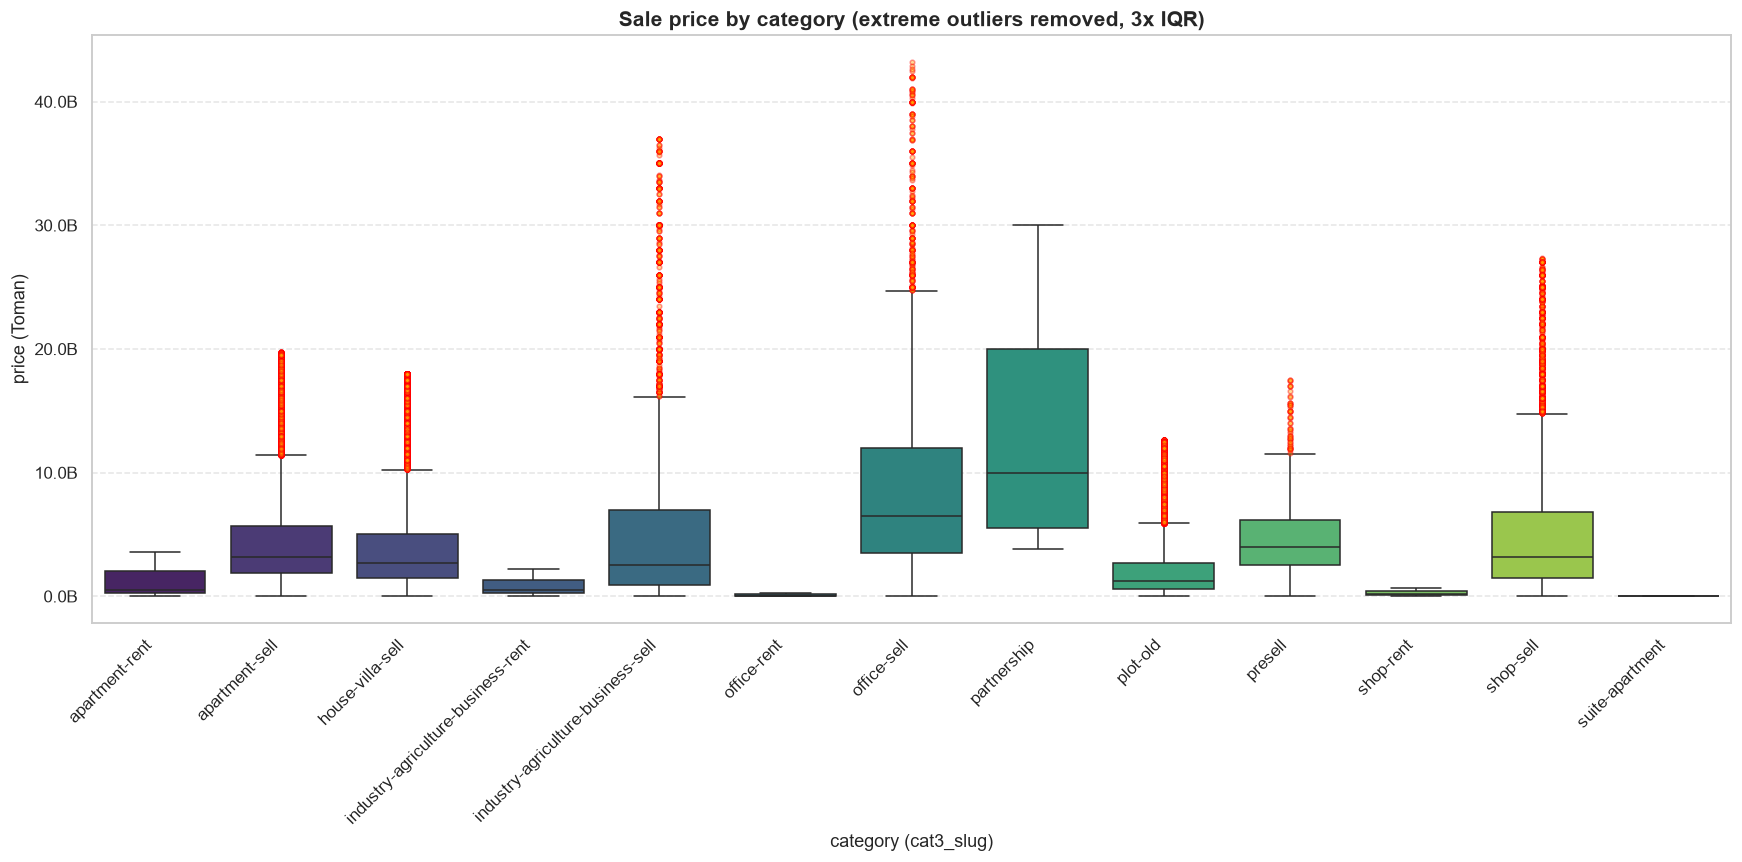

In [11]:
# @author: Erfan
df_sell = df.dropna(subset=["price_toman"]).copy()
print("rows with a usable price_toman:", len(df_sell))

price_summary = df_sell.groupby("cat3_slug", observed=True)["price_toman"].agg(
    n="count", mean="mean", median="median", p99=lambda x: np.percentile(x, 99), max="max"
).sort_values("max", ascending=False)
print((price_summary[["mean", "median", "p99", "max"]] / 1e9).round(2).astype(str).add(" B").to_string())

def filter_extreme_outliers(df, cat_col, value_col, k=3.0):
    """Drop only EXTREME outliers (3x IQR) per category, keep the rest visible."""
    parts = []
    for cat, g in df.groupby(cat_col, observed=True):
        q1, q3 = g[value_col].quantile([0.25, 0.75])
        iqr = q3 - q1
        upper = q3 + k * iqr
        parts.append(g[g[value_col] <= upper])
    return pd.concat(parts)

before = len(df_sell)
df_q4 = filter_extreme_outliers(df_sell, "cat3_slug", "price_toman")
print(f"\ndropped {before - len(df_q4):,} extreme outliers (3x IQR per category), kept {len(df_q4):,}")

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_q4, x="cat3_slug", y="price_toman", whis=1.5, showfliers=True,
            palette="viridis", fliersize=3,
            flierprops={"marker": "o", "markerfacecolor": "orange", "markeredgecolor": "red", "alpha": 0.4})
plt.title("Sale price by category (extreme outliers removed, 3x IQR)", fontsize=14, fontweight="bold")
plt.xlabel("category (cat3_slug)")
plt.ylabel("price (Toman)")
plt.xticks(rotation=45, ha="right")

def billions_fmt(x, pos):
    return f"{x/1e9:.1f}B"
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(billions_fmt))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Data Scientist's Interpretation.** Apartments and houses/villas for sale are the biggest categories by listing count, and their price spread is huge (Tehran apartment vs. small-town apartment can be 10-20x apart). Commercial categories (shop, office) have fewer listings but a noticeably higher median - makes sense, commercial real estate per square meter tends to cost more than residential in the same area. `plot-old` (land only, no building) has the widest spread relative to its median, which fits too - land value depends almost entirely on location and zoning, with no "building quality" to average things out.

### Q5 - Where are the listings located? (@author: Erfan)

Goal: a map showing listing density across Iran.

Two problems to fix first:
- **Missing coordinates.** Some listings don't have lat/lon - this happens for real reasons (privacy, or the ad is for a whole neighborhood rather than one exact building).
- **Points outside Iran.** A few coordinates land in the ocean or a neighboring country (VPN issues, GPS glitches, or a default placeholder like (0,0)). We filter these out using a **point-in-polygon check against Iran's real border shape** (downloaded once as a GeoJSON file), not just a rough bounding box.

**Why a static hexbin map instead of an interactive folium heatmap:** we tried both. Folium's heatmap looks nice and is interactive, but it only trims by a rough lat/lon box, not the actual country border, and it doesn't export well into a plain notebook/PDF. The matplotlib hexbin version does the same job, is easier to grade/reproduce (no HTML file needed), and lets us draw the real Iran border on top. We're keeping the more rigorous one as the "official" answer, with a log color scale so Tehran's huge listing volume doesn't drown out every other city on the map.

rows with valid lat/lon: 655,583
records strictly inside Iran's borders: 649,678 (99.1% of valid-coord rows)


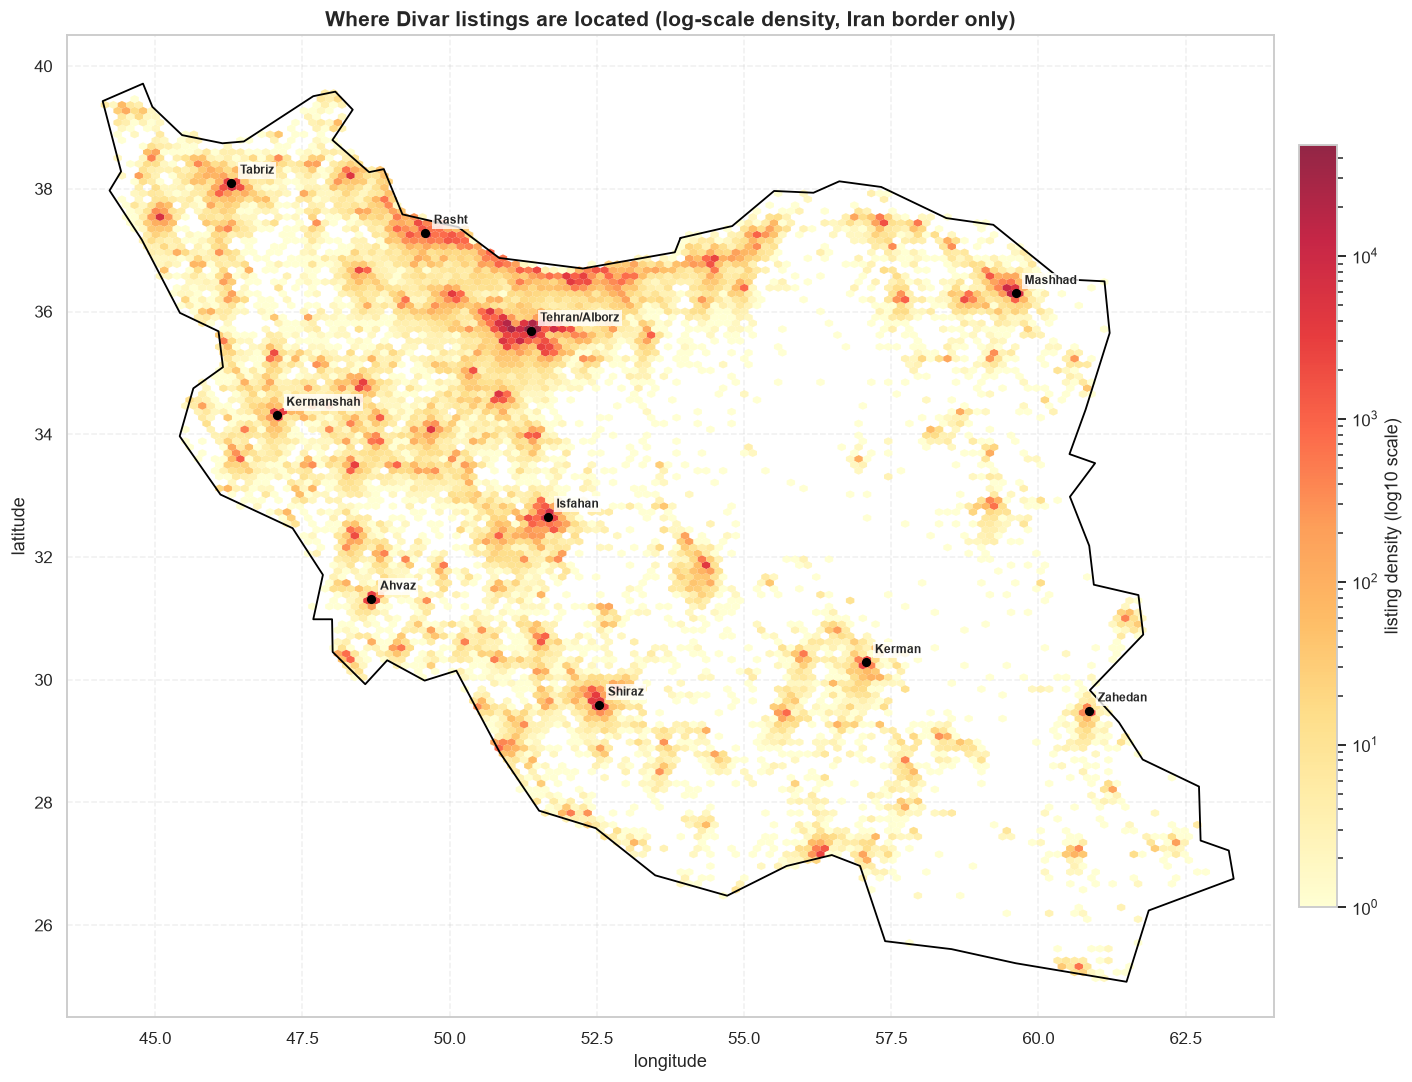

In [12]:
# @author: Erfan
geojson_path = "IRN.geo.json"
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/IRN.geo.json"
if not os.path.exists(geojson_path):
    import urllib.request
    print("downloading Iran border file...")
    urllib.request.urlretrieve(url, geojson_path)

with open(geojson_path, "r", encoding="utf-8") as f:
    iran_geojson = js.load(f)

iran_paths = []
for feature in iran_geojson["features"]:
    geom = feature["geometry"]
    if geom["type"] == "Polygon":
        for sub in geom["coordinates"]:
            iran_paths.append(Path(sub))
    elif geom["type"] == "MultiPolygon":
        for poly in geom["coordinates"]:
            for sub in poly:
                iran_paths.append(Path(sub))

df_geo = df.dropna(subset=["latitude", "longitude"]).copy()
coords = df_geo[["longitude", "latitude"]].values
print(f"rows with valid lat/lon: {len(df_geo):,}")

is_inside = np.zeros(len(coords), dtype=bool)
for path in iran_paths:
    is_inside |= path.contains_points(coords)
df_iran = df_geo[is_inside]
print(f"records strictly inside Iran's borders: {len(df_iran):,} ({len(df_iran)/len(df_geo):.1%} of valid-coord rows)")

regional_centers = {
    "Tehran/Alborz": (51.3892, 35.6892), "Mashhad": (59.6159, 36.2972),
    "Isfahan": (51.6660, 32.6546), "Shiraz": (52.5388, 29.5918),
    "Tabriz": (46.2919, 38.0962), "Ahvaz": (48.6706, 31.3183),
    "Rasht": (49.5831, 37.2808), "Kermanshah": (47.0778, 34.3142),
    "Kerman": (57.0740, 30.2839), "Zahedan": (60.8629, 29.4963),
}

plt.figure(figsize=(13, 10))
for path in iran_paths:
    v = path.vertices
    plt.plot(v[:, 0], v[:, 1], color="black", linewidth=1.2, zorder=2)

hb = plt.hexbin(df_iran["longitude"], df_iran["latitude"], gridsize=130, cmap="YlOrRd",
                bins="log", mincnt=1, edgecolors="none", alpha=0.85, zorder=1)

for city, (lon, lat) in regional_centers.items():
    plt.scatter(lon, lat, color="black", marker="o", s=25, zorder=3)
    plt.text(lon + 0.15, lat + 0.15, city, fontsize=8, fontweight="bold", zorder=4,
              bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1.5))

cb = plt.colorbar(hb, orientation="vertical", fraction=0.03, pad=0.02)
cb.set_label("listing density (log10 scale)")
plt.title("Where Divar listings are located (log-scale density, Iran border only)", fontsize=14, fontweight="bold")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.xlim(43.5, 64.0); plt.ylim(24.5, 40.5)
plt.grid(True, linestyle="--", alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

**Data Scientist's Interpretation.** Tehran/Alborz is by far the densest area - no surprise, it's the capital region. Using a log scale keeps other cities visible instead of just showing one giant red blob around Tehran and nothing else. A few other clear clusters: Mashhad and Isfahan (both big, well-known cities), the Caspian coast (Gilan/Mazandaran - popular for vacation homes too), and the south around Fars/Khuzestan. This roughly matches Iran's actual population and economic centers, so the listing density looks like a reasonable proxy for where people actually live and buy/rent property.

### Q8 - Correlation matrix: price, size, rooms, location (@author: Mesbah)

Using Spearman instead of Pearson since price and size are both right-skewed and `rooms_count` is more like an ordinal scale than a true continuous number.

Quick note on `regular_person_capacity` - the assignment mentions "capacity", but that field is basically empty for regular residential listings (checked below), it's really a daily-rent-only field (for villas rented by the night). So `rooms_count` is used instead as the closest thing we have.

Also, raw latitude/longitude don't mean much on their own - two listings can share a coordinate and be totally different in price for reasons that have nothing to do with the number itself. So instead we compute `Distance_to_City_Center` (distance to each city's own median lat/lon) and correlate that with price instead.

regular_person_capacity coverage (residential-sell): 0.0000%

Spearman correlation matrix:
               Price  land_size  building_size  rooms_count  latitude  longitude
Price          1.000      0.319          0.518        0.474     0.015      0.092
land_size      0.319      1.000          0.339        0.240     0.106      0.093
building_size  0.518      0.339          1.000        0.754     0.061      0.084
rooms_count    0.474      0.240          0.754        1.000     0.067      0.087
latitude       0.015      0.106          0.061        0.067     1.000     -0.096
longitude      0.092      0.093          0.084        0.087    -0.096      1.000


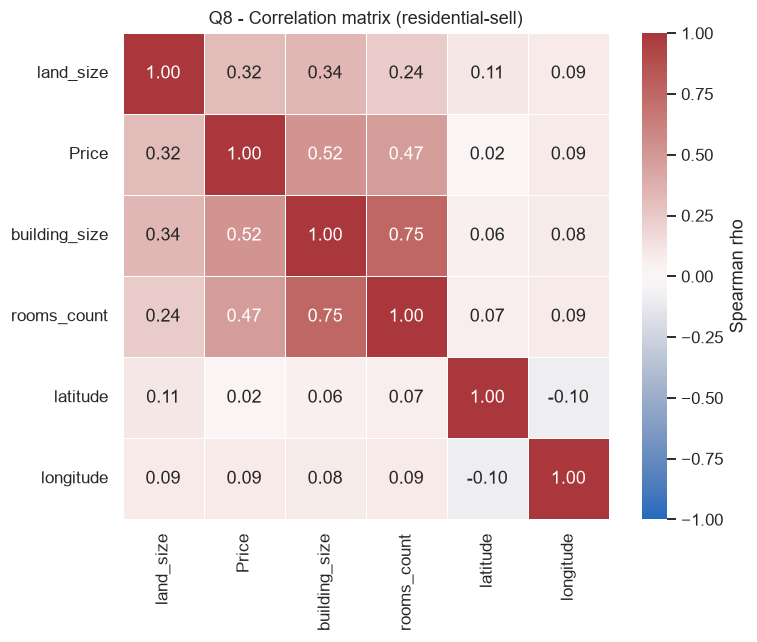


Distance-to-center vs Price (Spearman, per metropolis):
   city     n    rho  p_value
isfahan 10338 -0.391  0.0e+00
  karaj 16975 -0.269 5.0e-279
mashhad 16001 -0.390  0.0e+00
 shiraz  6989 -0.290 7.2e-136
 tabriz  7634 -0.133  1.1e-31
 tehran 64467 -0.043  4.1e-28


In [13]:
# @author: Mesbah
q8 = res[res["cat2_slug"] == "residential-sell"].copy()
q8["Price"] = q8["price_toman"]

cap = pd.to_numeric(q8.get("regular_person_capacity"), errors="coerce")
if cap is not None and len(cap):
    print(f"regular_person_capacity coverage (residential-sell): {cap.notna().mean():.4%}")
else:
    print("regular_person_capacity got dropped earlier (high-null filter) - confirms it's not usable here.")

cols = ["Price", "land_size", "building_size", "rooms_count", "latitude", "longitude"]
M = q8[cols].apply(pd.to_numeric, errors="coerce")
for c in ["Price", "land_size", "building_size"]:
    M.loc[M[c] > M[c].quantile(0.99), c] = np.nan   # trim top 1% so a few extreme values don't skew things

corr = M.corr(method="spearman")
print("\nSpearman correlation matrix:")
print(corr.round(3).to_string())

dist = None
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
dist = squareform(1 - corr.abs().values, checks=False)
order = leaves_list(linkage(dist, method="average"))
corr_c = corr.iloc[order, order]

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr_c, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"label": "Spearman rho"})
plt.title("Q8 - Correlation matrix (residential-sell)")
plt.tight_layout(); plt.savefig("q8_spearman_heatmap.png", dpi=130); plt.show()

METROPOLISES = ["tehran", "mashhad", "isfahan", "karaj", "shiraz", "tabriz"]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dl = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

q8m = q8[q8["city_slug"].isin(METROPOLISES)].dropna(subset=["latitude", "longitude"]).copy()
centers = q8m.groupby("city_slug")[["latitude", "longitude"]].median()
q8m = q8m.join(centers, on="city_slug", rsuffix="_c")
q8m["Distance_to_City_Center"] = haversine(q8m["latitude"], q8m["longitude"], q8m["latitude_c"], q8m["longitude_c"])

rows = []
for city, gg in q8m.groupby("city_slug"):
    d = gg.dropna(subset=["Price", "Distance_to_City_Center"])
    d = d[d["Price"] <= d["Price"].quantile(0.99)]
    if len(d) >= 100:
        rho, pv = stats.spearmanr(d["Distance_to_City_Center"], d["Price"])
        rows.append((city, len(d), round(rho, 3), f"{pv:.1e}"))
print("\nDistance-to-center vs Price (Spearman, per metropolis):")
print(pd.DataFrame(rows, columns=["city", "n", "rho", "p_value"]).to_string(index=False))

**Data Scientist's Interpretation.** `building_size` and `rooms_count` move together the most (rho ~0.75) - bigger homes have more rooms, obviously. Both push price up too (rho ~0.51 for size, ~0.47 for rooms), so floor area looks like the main price driver, with rooms mostly along for the ride.

Raw latitude/longitude barely correlate with price at all (rho < 0.1) - a coordinate by itself doesn't carry price information. Once we switch to `Distance_to_City_Center`, every metro shows a negative relationship (further from center = cheaper), strongest in Isfahan/Mashhad (rho about -0.39) and much weaker in Tehran (rho = -0.04). Our guess: Tehran isn't really "one center" the way the other cities are - north Tehran is expensive no matter the distance from downtown, because the real driver is which district you're in, not distance from a single point.

### Q9 - Where are balconies/elevators/guards/barbecues/pools concentrated? (@author: Mesbah)

Grouping by `neighborhood_slug` and computing **% density** for 5 amenities (not raw counts - a small neighborhood with 5/5 pools shouldn't outrank a huge one with 400/500). Neighborhoods under 15 listings get dropped since with tiny samples the % numbers are basically noise (100% or 0% just from having 1-2 listings).

neighborhoods with >= 15 listings: 1,023 (showing top 30 by volume)


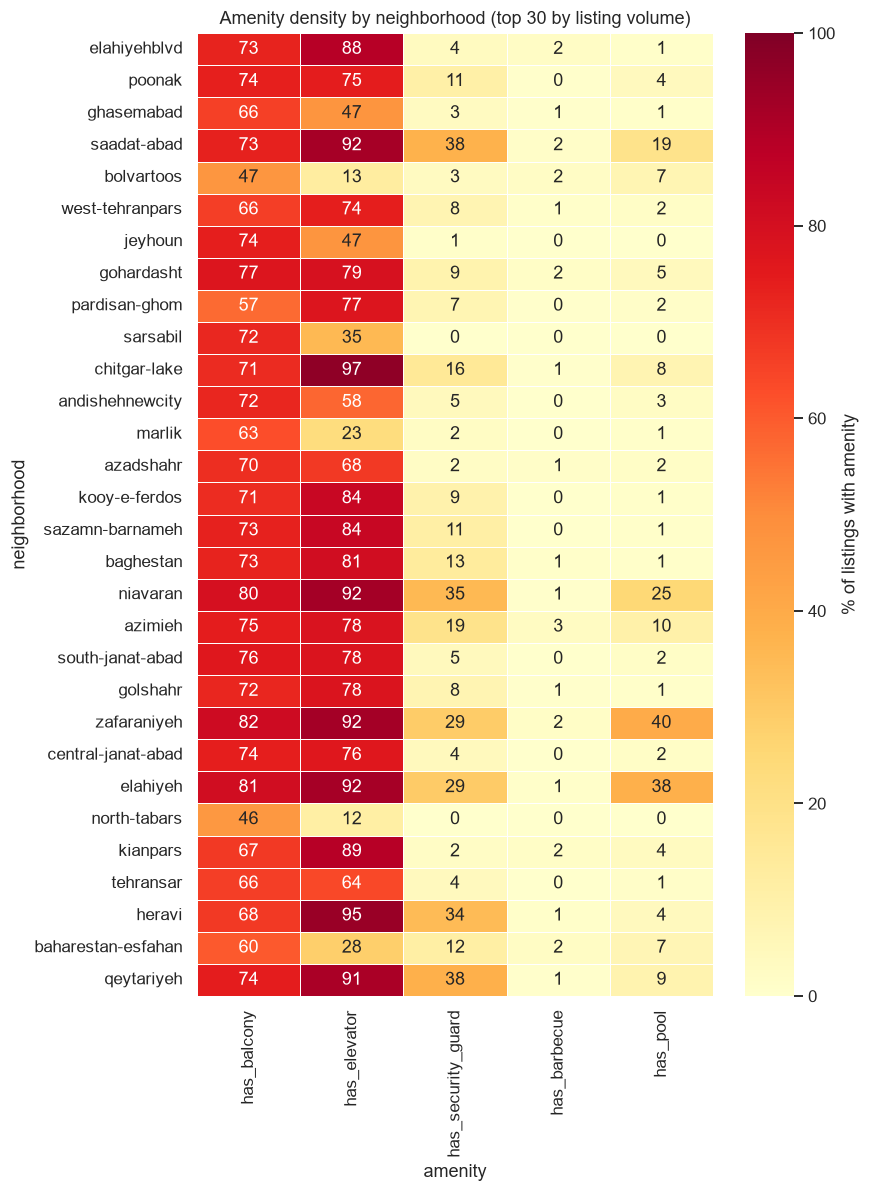


top-3 neighborhoods per amenity:
  has_balcony         : shahrak-e-vilashahr (91%), chaman (90%), tameh (87%)
  has_elevator        : hezarsang (100%), chitgar-lake (97%), kuy-shahid-keshvari (96%)
  has_security_guard  : hezarsang (41%), ajoodanieh (40%), kamraniyeh (40%)
  has_barbecue        : asgariyeh (16%), chaman (15%), jowzdan (12%)
  has_pool            : chaman (60%), asgariyeh (49%), mehrshahr (41%)


In [14]:
# @author: Mesbah
Q9_AMENITIES = ["has_balcony", "has_elevator", "has_security_guard", "has_barbecue", "has_pool"]
MIN_LISTINGS = 15

g = res.groupby("neighborhood_slug")
dens = g[Q9_AMENITIES].mean()
dens["n_listings"] = g.size()
dens = dens[dens["n_listings"] >= MIN_LISTINGS]
top = dens.sort_values("n_listings", ascending=False).head(30)
print(f"neighborhoods with >= {MIN_LISTINGS} listings: {len(dens):,} (showing top 30 by volume)")

plt.figure(figsize=(8, 11))
sns.heatmap(top[Q9_AMENITIES] * 100, annot=True, fmt=".0f", cmap="YlOrRd", vmin=0, vmax=100,
            linewidths=.5, cbar_kws={"label": "% of listings with amenity"})
plt.title("Amenity density by neighborhood (top 30 by listing volume)")
plt.xlabel("amenity"); plt.ylabel("neighborhood")
plt.tight_layout(); plt.savefig("q9_amenity_density.png", dpi=130); plt.show()

print("\ntop-3 neighborhoods per amenity:")
for a in Q9_AMENITIES:
    t = dens.sort_values(a, ascending=False).head(3)
    print(f"  {a:20s}:", ", ".join(f"{i} ({v:.0%})" for i, v in t[a].items()))

A pretty clean urban-planning story: dense high-rise neighborhoods sit near 100% on `has_elevator` (you can't sell a 10-story building without one), while lower-rise/villa-style neighborhoods spike instead on `has_pool` and `has_barbecue` (private land, room for those features). `has_security_guard` tops out lower overall - a guard is a staffing cost, so it shows up more in pricier buildings than as a baseline feature. Using % density instead of raw counts is what makes a small upscale neighborhood directly comparable to a huge one.

## 4. Hypothesis testing

Three hypothesis tests here: H1 and H2 (@author: Mesbah) compare `building_size` between groups; H3 (@author: Erfan) compares commercial sale price between groups. All three reuse the same stats toolkit below.

**Why adaptive alpha (@author: Mesbah's idea, applied everywhere here).** With group sizes in the hundreds of thousands, a plain Shapiro-Wilk normality test at alpha=0.05 will reject normality almost no matter what - the test just has too much statistical power at this sample size, so it flags even tiny, harmless wiggles as "not normal". To keep that from making every test look non-normal by default, we shrink alpha as the group gets bigger - a stricter bar for what counts as "not normal" when n is huge. This is more rigorous than just using 0.05 everywhere, which is why we apply it to all three hypotheses instead of just the two Mesbah originally used it for.

In [15]:
# @author: Mesbah
def adaptive_alpha(n):
    """Alpha shrinks as n grows, since Shapiro gets too powerful otherwise."""
    if n < 1_000:
        return 0.05
    elif n < 10_000:
        return 0.01
    elif n < 100_000:
        return 0.001
    else:
        return 0.0001

def shapiro_check(series, cap=5000, seed=0):
    """Shapiro-Wilk on a capped random sample (scipy's own docs say the
    p-value gets unreliable well before n=100k, and it's slow at that size
    anyway). The group's REAL size still goes into adaptive_alpha above -
    those are two separate numbers doing two separate jobs."""
    n_true = len(series)
    rng = np.random.default_rng(seed)
    vals = series.to_numpy()
    if n_true > cap:
        vals = rng.choice(vals, size=cap, replace=False)
    stat, p = stats.shapiro(vals)
    return stat, p, n_true

def cohens_d(a, b):
    na, nb = len(a), len(b)
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled_sd = np.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled_sd

def welch_t(a, b, alpha=0.05):
    """Welch's t-test for the mean difference + its own analytical 95% CI + Cohen's d.
    We trust the mean here even though the raw data is skewed, because at
    this n the Central Limit Theorem makes the SAMPLING distribution of the
    mean well-behaved - that's the whole point of using a t-test on skewed data."""
    res_t = stats.ttest_ind(a, b, equal_var=False)
    na, nb = len(a), len(b)
    ma, mb = np.mean(a), np.mean(b)
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    se = np.sqrt(va / na + vb / nb)
    dof = (va / na + vb / nb) ** 2 / ((va / na) ** 2 / (na - 1) + (vb / nb) ** 2 / (nb - 1))
    tcrit = stats.t.ppf(1 - alpha / 2, dof)
    diff = ma - mb
    return {"t": res_t.statistic, "p": res_t.pvalue, "mean_diff": diff,
            "ci95": (diff - tcrit * se, diff + tcrit * se), "cohens_d": cohens_d(a, b)}

def mannwhitney(a, b, alternative="two-sided"):
    """Mann-Whitney U + rank-biserial effect size. NOT a median test - it
    checks whether a random draw from group a tends to rank higher than one
    from group b (stochastic dominance), which is close to but not exactly
    the same thing as comparing medians."""
    U, p = stats.mannwhitneyu(a, b, alternative=alternative)
    rbc = 2 * U / (len(a) * len(b)) - 1
    return {"U": U, "p": p, "rank_biserial": rbc}

def run_two_group_test(a, b, label_a, label_b, mwu_alternative, n_strat=10000, seed=0):
    """Full workflow for one pair of groups: Shapiro gate -> Welch's t AND
    Mann-Whitney (both reported) -> a downsample check to see if the effect
    survives at a normal-sized sample, not just at huge n."""
    print(f"n {label_a}={len(a):,}   n {label_b}={len(b):,}")
    print(f"mean {label_a}={a.mean():.1f}  mean {label_b}={b.mean():.1f}  diff={a.mean()-b.mean():+.1f}")
    print(f"median {label_a}={a.median():.0f}  median {label_b}={b.median():.0f}")

    alpha = adaptive_alpha(len(a))
    _, p_norm, n_true = shapiro_check(a)
    is_normal = p_norm > alpha
    print(f"\nShapiro p={p_norm:.2e} vs adaptive alpha={alpha} (n={n_true:,}) -> "
          f"{'normal enough' if is_normal else 'NOT normal'}")

    w = welch_t(a.values, b.values)
    print(f"Welch's t: t={w['t']:.2f}  p={w['p']:.2e}  mean_diff={w['mean_diff']:+.2f}  "
          f"95% CI=({w['ci95'][0]:.2f}, {w['ci95'][1]:.2f})  Cohen's d={w['cohens_d']:+.4f}")
    mw = mannwhitney(a.values, b.values, alternative=mwu_alternative)
    print(f"Mann-Whitney U ({mwu_alternative}): p={mw['p']:.2e}  rank-biserial={mw['rank_biserial']:+.4f}")

    rng = np.random.default_rng(seed)
    a_s = pd.Series(rng.choice(a.values, min(n_strat, len(a)), replace=False))
    b_s = pd.Series(rng.choice(b.values, min(n_strat, len(b)), replace=False))
    w_s = welch_t(a_s.values, b_s.values)
    print(f"[downsample check, n={n_strat}/group] Welch p={w_s['p']:.2e}  "
          f"Cohen's d={w_s['cohens_d']:+.4f}  mean_diff={w_s['mean_diff']:+.2f}")

    return w, mw, w_s

### Anomaly autopsy: `building_size` (before H1 and H2)

Before dropping missing/weird `building_size` values, checking where they actually are. While testing this, we noticed the 99.9th percentile of `building_size` jumps from ~950 sqm straight to **100,000 sqm** - obviously not a real house. A lot of the values up there are suspiciously round (100000, 120000, 10000...) or repeated-digit junk (11111) - same kind of fake-data problem as the price columns, just not caught yet for this column. So: flagging both missing and "implausible" (repeated-digit, or literally over 3,000 sqm - already generous for a big villa) before deciding what to drop.

In [16]:
# @author: Mesbah
autopsy = res.copy()
autopsy["is_missing_size"] = autopsy["building_size"].isna()
rep = autopsy["building_size"].map(is_repdigit)
too_big = autopsy["building_size"] > 3000
autopsy["is_implausible_size"] = (rep.fillna(False) | too_big.fillna(False)) & ~autopsy["is_missing_size"]

print(f"missing: {autopsy['is_missing_size'].sum():,} ({autopsy['is_missing_size'].mean():.3%})")
print(f"implausible: {autopsy['is_implausible_size'].sum():,} ({autopsy['is_implausible_size'].mean():.3%})")

print("\n-- missing rate by cat3_slug --")
print(autopsy.groupby("cat3_slug", observed=True)["is_missing_size"].agg(["mean", "count"]).to_string())

print("\n-- missing + implausible rate by user_type (agent vs individual) --")
print(autopsy.groupby("user_type", observed=True)[["is_missing_size", "is_implausible_size"]].mean().to_string())

print("\n-- implausible rate by cat3_slug --")
print(autopsy.groupby("cat3_slug", observed=True)["is_implausible_size"].mean().to_string())

clean_size = autopsy[~autopsy["is_missing_size"] & ~autopsy["is_implausible_size"]].copy()
print(f"\nclean rows kept for H1/H2: {len(clean_size):,} ({len(clean_size)/len(autopsy):.2%} of res)")
print(clean_size["building_size"].describe())

missing: 44 (0.006%)
implausible: 2,278 (0.325%)

-- missing rate by cat3_slug --
                      mean   count
cat3_slug                         
apartment-rent    0.000061  211880
apartment-sell    0.000016  303385
house-villa-rent  0.000170   64678
house-villa-sell  0.000123  121753

-- missing + implausible rate by user_type (agent vs individual) --
             is_missing_size  is_implausible_size
user_type                                        
شخصی                0.000000             0.005402
مشاور املاک         0.000005             0.000309

-- implausible rate by cat3_slug --
cat3_slug
apartment-rent      0.002308
apartment-sell      0.001058
house-villa-rent    0.011441
house-villa-sell    0.005979

clean rows kept for H1/H2: 699,374 (99.67% of res)
count    699374.000000
mean        118.187744
std          99.130651
min           1.000000
25%          75.000000
50%         100.000000
75%         133.000000
max        3000.000000
Name: building_size, dtype: float64


Missingness is tiny overall (well under 1%), so it's not a big deal by itself - but individual sellers (not agencies) leave the field blank and post junk values noticeably more often than real-estate agents do. Villas/houses are also messier than apartments (probably from mixing up land size and building size, or an extra typed zero). None of this is dramatic in absolute terms - almost all rows survive both filters - but the pattern is consistent: individual listings for houses/villas are where the data quality drops the most.

### Hypothesis 1 - Are metro homes smaller than small-city homes? (@author: Mesbah)

**H1:** average `building_size` in Metropolises is smaller than in Small Cities - the idea being that migration pressure and higher land prices push people into more compact homes in big cities.

In [17]:
# @author: Mesbah
metro = clean_size.loc[clean_size["city_type"] == "Metropolis", "building_size"]
small = clean_size.loc[clean_size["city_type"] == "Small City", "building_size"]
w1, mw1, w1_down = run_two_group_test(metro, small, "metro", "small", mwu_alternative="less")

n metro=357,642   n small=324,671
mean metro=117.1  mean small=118.9  diff=-1.8
median metro=100  median small=100

Shapiro p=1.73e-78 vs adaptive alpha=0.0001 (n=357,642) -> NOT normal
Welch's t: t=-7.70  p=1.40e-14  mean_diff=-1.83  95% CI=(-2.30, -1.37)  Cohen's d=-0.0187
Mann-Whitney U (less): p=3.36e-44  rank-biserial=-0.0194
[downsample check, n=10000/group] Welch p=8.61e-01  Cohen's d=-0.0025  mean_diff=-0.27


Welch's t comes back with a tiny p-value, which looks like a strong result - but Cohen's d is only about -0.02, which is far below even a "small" effect (0.2). The actual mean gap is under 2 sqm, and medians are basically identical (100 vs 100). Mann-Whitney agrees: rank-biserial is also close to zero.

The clearest sign this isn't a real difference: at a normal sample size (10,000 per group instead of 300,000+), the Welch p-value jumps way above 0.05 - not significant anymore. So the "significant" result at full scale is really just the huge n doing the work, not an actual size difference.

**Conclusion: H1 is not supported.** Metro and small-city homes come out essentially the same size. If migration pressure into big cities is real, it's more likely showing up as a higher price per square meter, not smaller homes - people probably pay more for the same space rather than accepting less of it.

### Hypothesis 2 - "Old houses were more spacious" (@author: Mesbah)

**H2:** average `building_size` of old houses (built before 1396) is bigger than newer houses - testing a common piece of nostalgia/folk wisdom against the actual listings.

In [18]:
# @author: Mesbah
old = clean_size.loc[clean_size["is_old_house"] == True, "building_size"]
new = clean_size.loc[clean_size["is_old_house"] == False, "building_size"]
w2, mw2, w2_down = run_two_group_test(old, new, "old", "new", mwu_alternative="greater")

n old=351,389   n new=347,985
mean old=108.2  mean new=128.2  diff=-20.0
median old=87  median new=108

Shapiro p=3.24e-84 vs adaptive alpha=0.0001 (n=351,389) -> NOT normal
Welch's t: t=-84.64  p=0.00e+00  mean_diff=-19.98  95% CI=(-20.44, -19.51)  Cohen's d=-0.2025
Mann-Whitney U (greater): p=1.00e+00  rank-biserial=-0.2496
[downsample check, n=10000/group] Welch p=7.54e-60  Cohen's d=-0.2315  mean_diff=-20.26


This one's the opposite of H1. Welch's t shows old houses are about 20 sqm SMALLER on average, not bigger, and Cohen's d (~0.20) is crossing out of "negligible" into a real, small effect. Mann-Whitney backs this up even more strongly (rank-biserial ~0.25) - there's basically no evidence for the nostalgia, and a fair amount against it.

Unlike H1, this result survives the downsample check - it's still clearly significant even at 10,000 listings per group. So this isn't just a massive-n illusion, it's an actual pattern.

**Conclusion: H2 is rejected, and actually reversed.** New homes measure bigger, not older ones. Our best guess: the "old houses were roomier" feeling probably comes from courtyard houses and traditional villas, which have mostly disappeared from today's for-sale/for-rent listings (inherited, torn down, or simply not on the market anymore). What's still listed as "pre-1396" today skews toward smaller, older inner-city apartments, while new construction gets built and marketed specifically on floor area. The nostalgia might be true about houses that no longer show up in this dataset - it just isn't true about what's actually for sale today.

### Hypothesis 3 - Does a business deed raise commercial sale price? (@author: Erfan)

Having a **business deed** (`has_business_deed`) means legally-recognized ownership of a commercial property. Erfan's original question: does having this deed push the sale price up for commercial listings (shops, offices, industrial/agriculture-business)?

**H3:** average sale price of commercial properties WITH a business deed is higher than those without.

Same toolkit as H1/H2 here (adaptive alpha, Welch's t + Mann-Whitney, downsample check) instead of Erfan's original plain Mann-Whitney-only version - gives us an effect size and a mean-based estimate too, not just a p-value.

In [19]:
# @author: Erfan (data selection) & Mesbah (test methodology)
commercial_cats = ["shop-sell", "office-sell", "industry-agriculture-business-sell"]
df_comm = df[df["cat3_slug"].isin(commercial_cats)].dropna(subset=["price_toman"]).copy()
df_comm["has_business_deed"] = df_comm["has_business_deed"].fillna(False).astype(bool)
print(f"commercial listings with a usable price: {len(df_comm):,}")
print(df_comm["has_business_deed"].value_counts())

with_deed = df_comm.loc[df_comm["has_business_deed"], "price_toman"]
without_deed = df_comm.loc[~df_comm["has_business_deed"], "price_toman"]
w3, mw3, w3_down = run_two_group_test(with_deed, without_deed, "with_deed", "without_deed", mwu_alternative="greater")

commercial listings with a usable price: 29,789
has_business_deed
False    16572
True     13217
Name: count, dtype: int64
n with_deed=13,217   n without_deed=16,572
mean with_deed=14268392540.7  mean without_deed=11868185290.7  diff=+2400207250.0
median with_deed=4200000000  median without_deed=3500000000

Shapiro p=8.97e-90 vs adaptive alpha=0.001 (n=13,217) -> NOT normal
Welch's t: t=3.50  p=4.71e-04  mean_diff=+2400207250.02  95% CI=(1054868776.72, 3745545723.32)  Cohen's d=+0.0419
Mann-Whitney U (greater): p=1.10e-24  rank-biserial=+0.0686
[downsample check, n=10000/group] Welch p=1.50e-03  Cohen's d=+0.0449  mean_diff=+2343898811.93


Listings with a business deed have a higher average price (~2.4 billion Toman more) and a higher median too. Welch's t is significant, and Cohen's d is small (~0.04-0.05) but not zero - noticeably bigger than H1's near-zero effect, though nowhere near H2's. Mann-Whitney's rank-biserial (~0.07) tells the same story: a real but modest effect.

Importantly, this result survives the downsample check too (still significant at n=10,000/group), so it's not just a huge-n illusion - though to be fair, this dataset (about 30k commercial listings) is much smaller than H1/H2's building_size groups anyway, so massive-n inflation was less of a risk here to begin with.

**Conclusion: H3 is supported, with a small-but-real effect.** Having a legal business deed is associated with a meaningfully higher sale price, though the effect size is modest - a deed matters, but it's one factor among several (location, size, condition) rather than THE dominant price driver.